In [ ]:
!git clone https://github.com/ManuelHirsch1/TP1_rrnn.git

fatal: destination path 'TP1_rrnn' already exists and is not an empty directory.
panda_original_recuperado.png  TP1_rrnn/
perro_original_recuperado.png  vesquinas_original_parcial_recuperado.png
sample_data/		       v_original_recuperado.png
paloma.bmp  panda.bmp  perro.bmp  quijote.bmp  torero.bmp  v.bmp


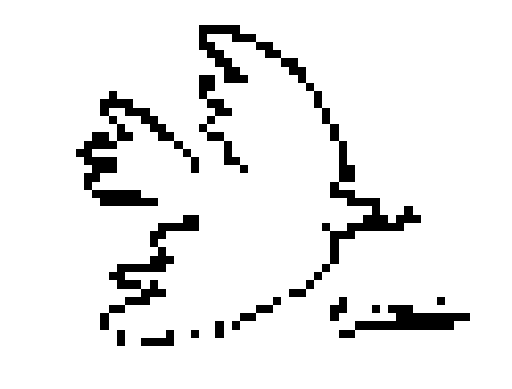

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg



path_imagen = 'TP1_rrnn/img/paloma.bmp'

if os.path.exists(path_imagen):
    img = mpimg.imread(path_imagen)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f'No se encontró la imagen en: {path_imagen}')

In [ ]:
import os
import matplotlib.image as mpimg

# Ruta a la carpeta de imágenes
image_dir = 'TP1_rrnn/img/'  # Corregido: 'TP1_rrnn' en lugar de 'TP1_rnn'

# Listar todas las imágenes en la carpeta
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.bmp'))]

print(f"Imágenes disponibles en '{image_dir}':")
if image_files:
    for img_file in image_files:
        file_path = os.path.join(image_dir, img_file)
        try:
            # Cargar la imagen para obtener sus dimensiones
            img = mpimg.imread(file_path)
            # mpimg.imread devuelve un array numpy. Su shape es (alto, ancho) o (alto, ancho, canales)
            height, width = img.shape[0], img.shape[1]
            print(f"- {img_file} (Dimensiones: {width}x{height} píxeles)")
        except Exception as e:
            print(f"- {img_file} (Error al leer dimensiones: {e})")
else:
    print("No se encontraron imágenes en la carpeta especificada.")

Imágenes disponibles en 'TP1_rrnn/img/':
- v.bmp (Dimensiones: 50x50 píxeles)
- quijote.bmp (Dimensiones: 60x45 píxeles)
- perro.bmp (Dimensiones: 50x50 píxeles)
- panda.bmp (Dimensiones: 50x50 píxeles)
- paloma.bmp (Dimensiones: 60x45 píxeles)
- torero.bmp (Dimensiones: 60x45 píxeles)


In [ ]:
import numpy as np


# Para hacer solo con las de 50x50
selected_image_files = ['panda.bmp', 'perro.bmp', 'v.bmp']

# Lista para almacenar los patrones binarizados y aplanados de las imágenes seleccionadas
patterns_selected = []

# Guardar las dimensiones de las imágenes para reconstruirlas después
image_shapes_selected = {}

for img_file in selected_image_files:
    file_path = os.path.join(image_dir, img_file)

    img_data = mpimg.imread(file_path)

    img_data_single_channel = img_data[:, :, 0]

    img_binary = np.where(img_data_single_channel == 255, 1, -1)
    image_shapes_selected[img_file] = img_binary.shape
    patterns_selected.append(img_binary.flatten())

patterns_selected = np.array(patterns_selected)

print(f"\nTotal de patrones cargados: {len(patterns_selected)}")
print(f"Dimensiones del array de patrones: {patterns_selected.shape}")
# Verificar que todos los patrones tienen la misma longitud
if patterns_selected.shape[0] > 0:
    print(f"Longitud de cada patrón: {patterns_selected.shape[1]}")
else:
    print("No se cargaron patrones.")


Total de patrones cargados: 3
Dimensiones del array de patrones: (3, 2500)
Longitud de cada patrón: 2500


In [ ]:
import numpy as np

class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.n = num_neurons
        self.weights = np.zeros((self.n, self.n))

    def train(self, patterns):
        for pattern in patterns:
            # Entrenamiento clásico usando la regla de Hebb
            self.weights += np.outer(pattern, pattern)

        # Poner a cero la diagonal para evitar auto-conexiones
        np.fill_diagonal(self.weights, 0)
        return self

    def retrieve(self, pattern_in, max_epochs=100):
        # Usamos .copy() para no sobreescribir la imagen original que le pasas
        X = pattern_in.copy()
        history = [X.copy()]
        actual_epochs = 0

        for _ in range(max_epochs):
            # Guardamos una copia REAL del estado antes de empezar la época
            old_X = X.copy()

            for i in np.random.choice(np.arange(self.n), size=self.n, replace=False):
                # Producto punto (input neto de la neurona)
                net_input = np.dot(self.weights[i, :], X)

                # Asignamos 1 o -1, evitando la trampa de np.sign(0) == 0
                X[i] = 1 if net_input >= 0 else -1

            # Guardamos el estado al final de la época y sumamos 1 al contador
            history.append(X.copy())
            actual_epochs += 1

            # Si el estado no cambió en toda la época, la red convergió
            if np.array_equal(X, old_X):
                break

        # Devuelve exactamente lo que pediste
        return X, history, actual_epochs

Verificando si los patrones de entrenamiento son puntos fijos estables...

Procesando: panda.bmp
Iteraciones para converger: 1


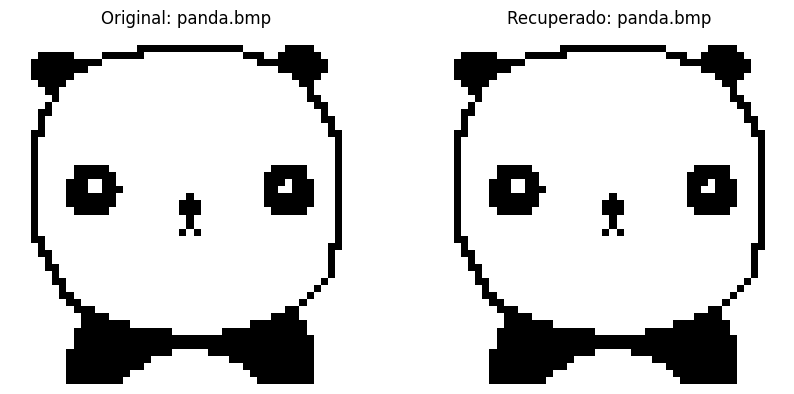


Procesando: perro.bmp
Iteraciones para converger: 1


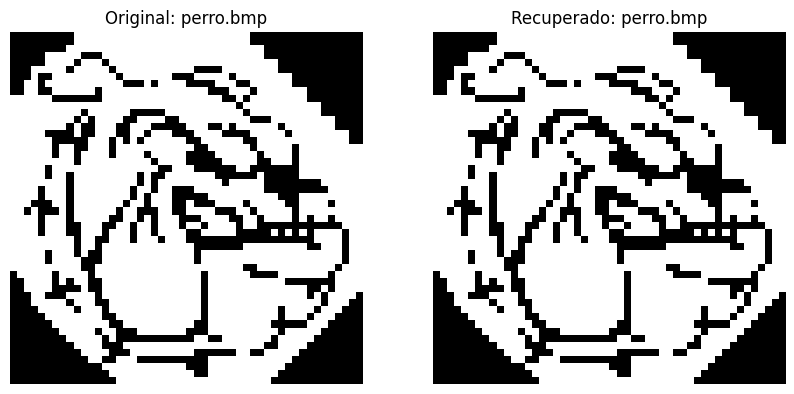


Procesando: v.bmp
Iteraciones para converger: 1


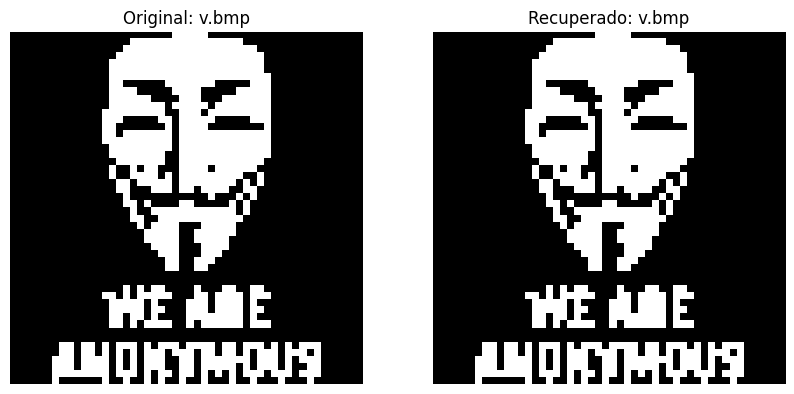

In [ ]:
num_neurons = patterns_selected.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(patterns_selected)

def plot_pattern(pattern, shape, title=""):
    plt.imshow(pattern.reshape(shape), cmap='gray')
    plt.title(title)
    plt.axis('off')

print("Verificando si los patrones de entrenamiento son puntos fijos estables...")

correctly_retrieved_count = 0

for i, original_pattern in enumerate(patterns_selected):
      img_file = selected_image_files[i]
      original_shape = image_shapes_selected[img_file]

      print(f"\nProcesando: {img_file}")

      # Presentar el patrón original a la red para ver si lo recupera sin cambios
      retrieved_pattern, _, actual_iterations = hopfield_network.retrieve(original_pattern)

      # Mostrar la cantidad de iteraciones
      print(f"Iteraciones para converger: {actual_iterations}")

      # Siempre visualizar el original y el recuperado, independientemente de si son idénticos
      plt.figure(figsize=(10, 5))

      original_pattern_addapted = np.where(original_pattern == 1, 255, 0)
      retrieved_pattern_addapted = np.where(retrieved_pattern == 1, 255, 0)

      plt.subplot(1, 2, 1)
      plot_pattern(original_pattern_addapted, original_shape, f'Original: {img_file}')

      plt.subplot(1, 2, 2)
      plot_pattern(retrieved_pattern_addapted, original_shape, f'Recuperado: {img_file}')

      # Guardar la figura antes de mostrarla
      plt.savefig(f'{img_file.replace(".bmp", "")}_original_recuperado.png')
      plt.show()

Evaluando la recuperación de 'v.bmp' con cuadrados blancos en las esquinas...

--- Añadiendo cuadrados de 1x1 píxeles blancos en las esquinas a 'v.bmp' ---


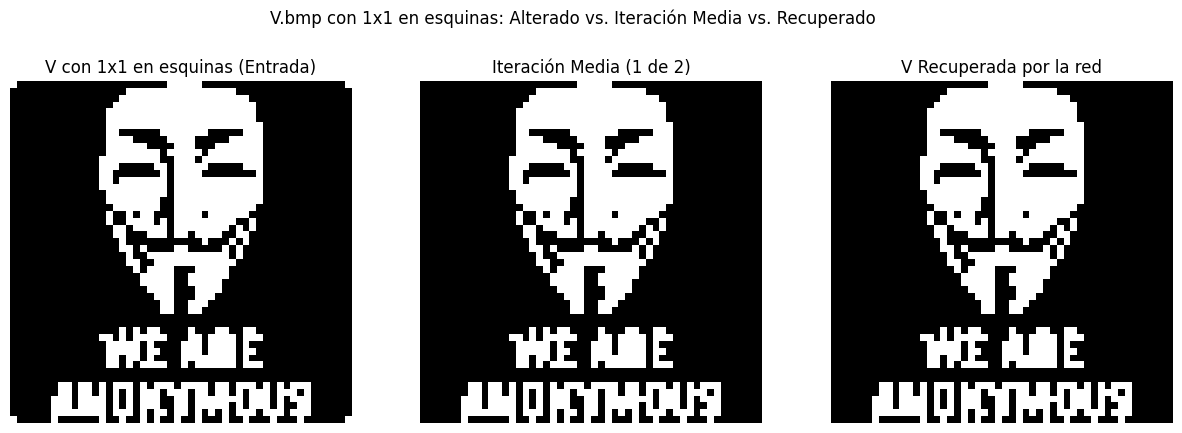

La red tomó 2 iteraciones para recuperar la imagen con cuadrados de 1x1 en las esquinas.

--- Añadiendo cuadrados de 5x5 píxeles blancos en las esquinas a 'v.bmp' ---


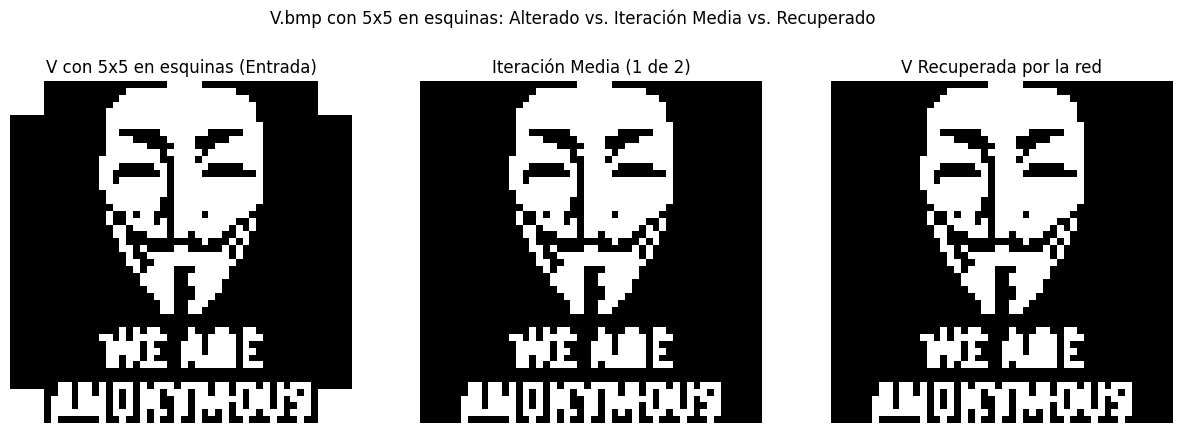

La red tomó 2 iteraciones para recuperar la imagen con cuadrados de 5x5 en las esquinas.

--- Añadiendo cuadrados de 10x10 píxeles blancos en las esquinas a 'v.bmp' ---


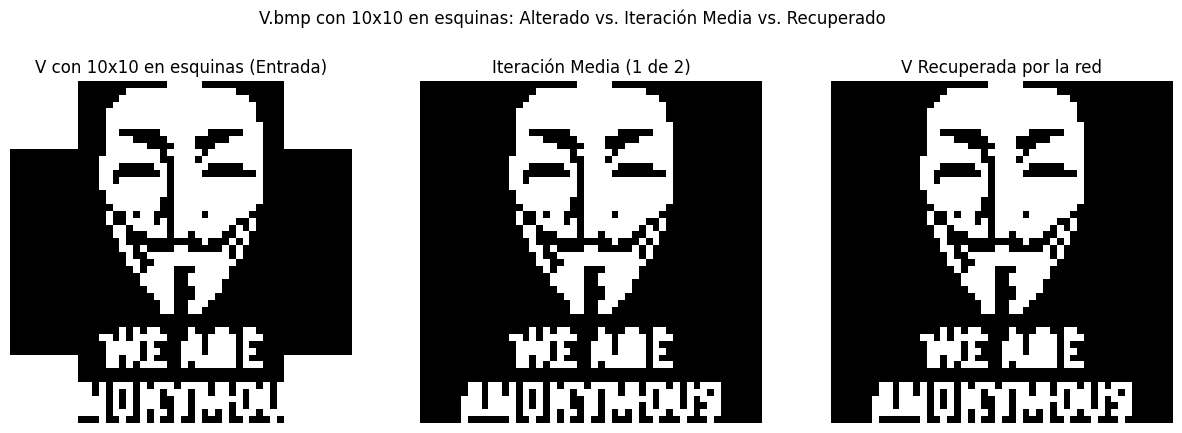

La red tomó 2 iteraciones para recuperar la imagen con cuadrados de 10x10 en las esquinas.

--- Añadiendo cuadrados de 20x20 píxeles blancos en las esquinas a 'v.bmp' ---


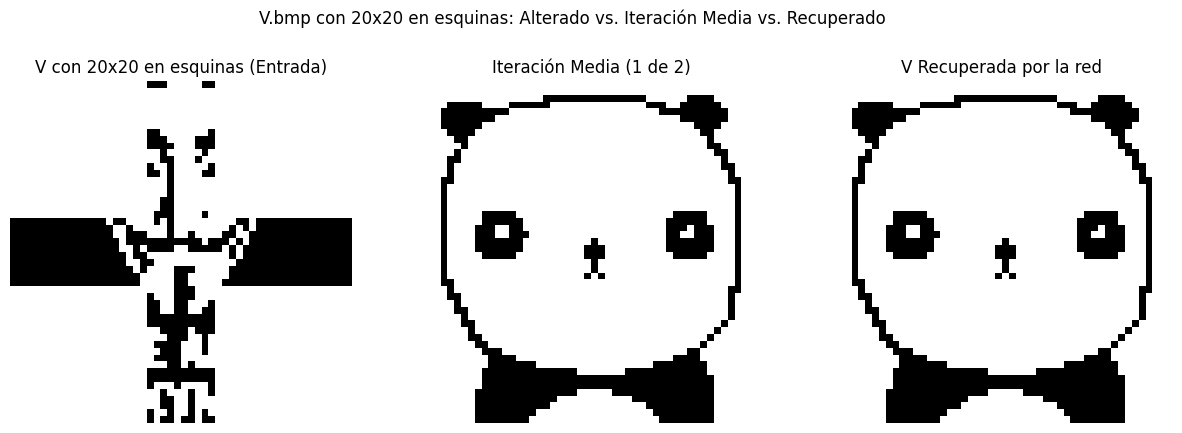

La red tomó 2 iteraciones para recuperar la imagen con cuadrados de 20x20 en las esquinas.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_neurons = patterns_selected.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(patterns_selected)

def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

# 1. Obtener el patrón original de v.bmp y su forma una sola vez
idx_v = selected_image_files.index('v.bmp')
original_v_pattern_flat = patterns_selected[idx_v].copy()
oriented_v_shape = image_shapes_selected['v.bmp']
height, width = oriented_v_shape

# Definir los tamaños de los cuadrados a añadir en las esquinas
square_sizes_list = [1, 5, 10, 20]

print("Evaluando la recuperación de 'v.bmp' con cuadrados blancos en las esquinas...")

for square_size in square_sizes_list:
    print(f"\n--- Añadiendo cuadrados de {square_size}x{square_size} píxeles blancos en las esquinas a 'v.bmp' ---")

    # Empezar con el patrón original para cada iteración
    modified_v_2d = original_v_pattern_flat.reshape(oriented_v_shape).copy()

    # Añadir cuadrados blancos en las cuatro esquinas
    # Esquina superior izquierda
    modified_v_2d[0:square_size, 0:square_size] = 1
    # Esquina superior derecha
    modified_v_2d[0:square_size, width-square_size:width] = 1
    # Esquina inferior izquierda
    modified_v_2d[height-square_size:height, 0:square_size] = 1
    # Esquina inferior derecha
    modified_v_2d[height-square_size:height, width-square_size:width] = 1

    modified_v_pattern_flat = modified_v_2d.flatten()

    # Pasar la imagen modificada por la función retrieve de la red de Hopfield
    retrieved_v_pattern, history, actual_iterations = hopfield_network.retrieve(modified_v_pattern_flat)

    # Seleccionar una iteración 'media' si hay suficientes pasos
    middle_iteration_pattern = None
    middle_iteration_index = (actual_iterations + 1) // 2
    if len(history) > middle_iteration_index:
        middle_iteration_pattern = history[middle_iteration_index]
    else:
        # Fallback if history is too short for a distinct middle, though history always includes start and end
        middle_iteration_pattern = history[0] # Fallback to initial state if no distinct middle

    # Imprimir la imagen con los píxeles blancos, la iteración media y la imagen recuperada
    plt.figure(figsize=(15, 5)) # Aumentar el tamaño para 3 subplots
    plt.suptitle(f'V.bmp con {square_size}x{square_size} en esquinas: Alterado vs. Iteración Media vs. Recuperado')

    plt.subplot(1, 3, 1) # Cambiar a 1 fila, 3 columnas
    plot_pattern(adapt_for_plot(modified_v_pattern_flat), oriented_v_shape, f'V con {square_size}x{square_size} en esquinas (Entrada)')

    plt.subplot(1, 3, 2) # Nuevo subplot para la iteración media
    plot_pattern(adapt_for_plot(middle_iteration_pattern), oriented_v_shape, f'Iteración Media ({middle_iteration_index} de {actual_iterations})')

    plt.subplot(1, 3, 3) # Cambiar a la tercera posición
    plot_pattern(adapt_for_plot(retrieved_v_pattern), oriented_v_shape, 'V Recuperada por la red')
    plt.savefig(f'{img_file.replace(".bmp", "")}esquinas_original_parcial_recuperado.png')
    plt.show()

    # Aclarar el número de iteraciones
    print(f"La red tomó {actual_iterations} iteraciones para recuperar la imagen con cuadrados de {square_size}x{square_size} en las esquinas.")

Evaluando la recuperación de 'perro.bmp' con diagonales negras de diferentes grosores...

--- Añadiendo diagonales negras de 3 píxeles de grosor a 'perro.bmp' ---


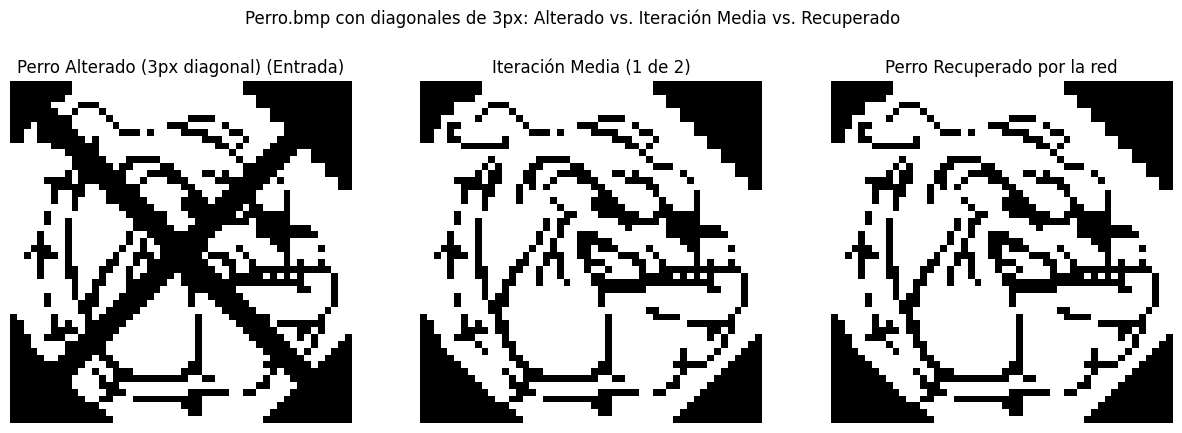

La red tomó 2 iteraciones para recuperar la imagen con diagonales de 3 píxeles.

--- Añadiendo diagonales negras de 8 píxeles de grosor a 'perro.bmp' ---


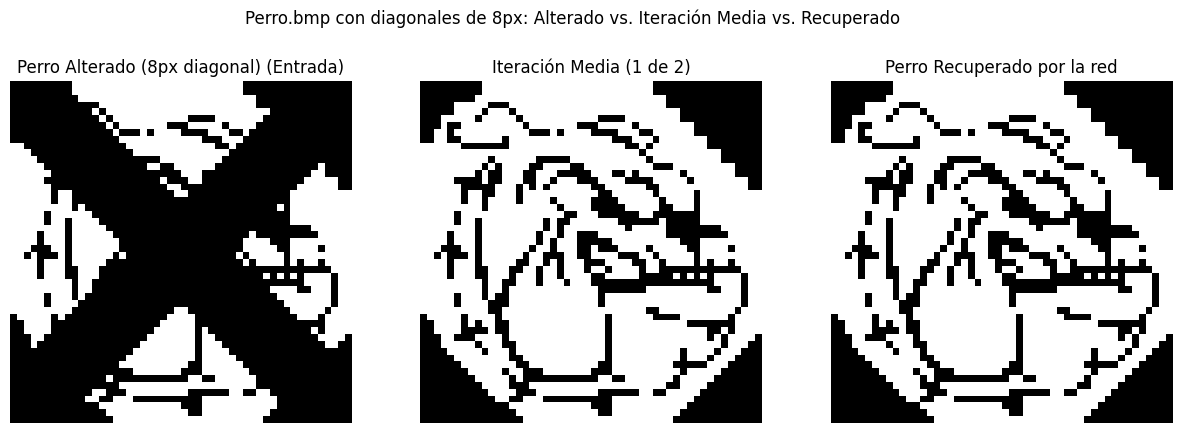

La red tomó 2 iteraciones para recuperar la imagen con diagonales de 8 píxeles.

--- Añadiendo diagonales negras de 10 píxeles de grosor a 'perro.bmp' ---


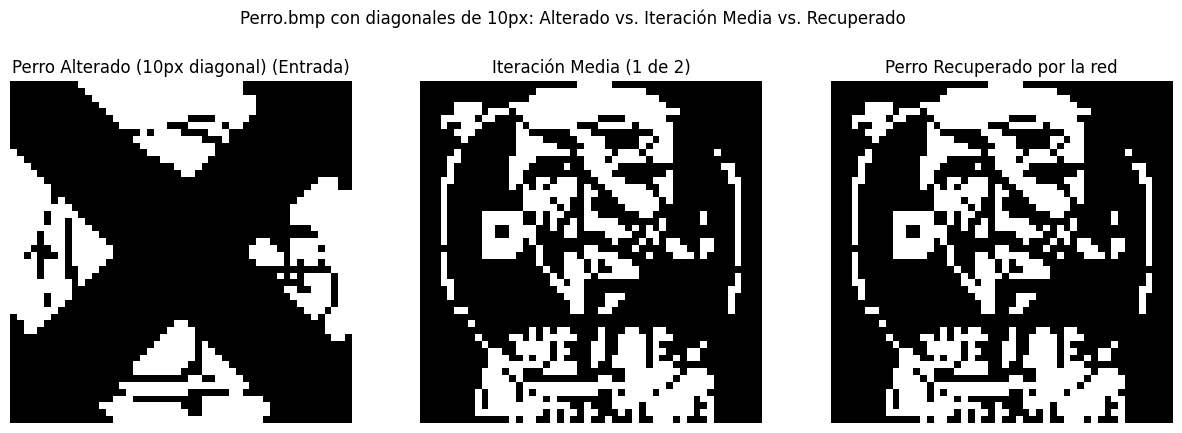

La red tomó 2 iteraciones para recuperar la imagen con diagonales de 10 píxeles.

El estado espurio de ejemplo (para la diagonal de 10 píxeles) tiene la forma: (2500,)


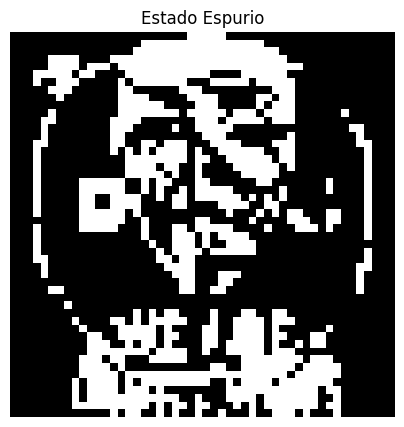

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_neurons = patterns_selected.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(patterns_selected)

def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

# 1. Obtener el patrón original de perro.bmp y su forma una sola vez
idx_perro = selected_image_files.index('perro.bmp')
original_perro_pattern_flat = patterns_selected[idx_perro].copy()
oriented_perro_shape = image_shapes_selected['perro.bmp']
height, width = oriented_perro_shape

# Definir los grosores de las diagonales
diagonal_thicknesses = [3, 8, 10]

print("Evaluando la recuperación de 'perro.bmp' con diagonales negras de diferentes grosores...")

estado_espurio_ejemplo = None # Inicializar la variable

for thickness in diagonal_thicknesses:
    print(f"\n--- Añadiendo diagonales negras de {thickness} píxeles de grosor a 'perro.bmp' ---")

    # Empezar con el patrón original para cada iteración
    modified_perro_2d = original_perro_pattern_flat.reshape(oriented_perro_shape).copy()

    # Añadir diagonales negras (valor -1)
    for i in range(height):
        for j in range(width):
            # Diagonal principal
            if abs(i - j) < thickness:
                modified_perro_2d[i, j] = -1
            # Diagonal secundaria
            if abs(i + j - (width - 1)) < thickness:
                modified_perro_2d[i, j] = -1

    modified_perro_pattern_flat = modified_perro_2d.flatten()

    # Pasar la imagen modificada por la función retrieve de la red de Hopfield
    retrieved_perro_pattern, history, actual_iterations = hopfield_network.retrieve(modified_perro_pattern_flat)

    # Guardar el patrón recuperado si el grosor es 10
    if thickness == 10:
        estado_espurio_ejemplo = retrieved_perro_pattern.copy()

    # Seleccionar una iteración 'media' si hay suficientes pasos
    middle_iteration_pattern = None
    middle_iteration_index = (actual_iterations + 1) // 2
    if len(history) > middle_iteration_index:
        middle_iteration_pattern = history[middle_iteration_index]
    else:
        # Fallback if history is too short for a distinct middle, though history always includes start and end
        middle_iteration_pattern = history[0] # Fallback to initial state if no distinct middle

    # Imprimir la imagen con las diagonales, la iteración media y la imagen recuperada
    plt.figure(figsize=(15, 5)) # Aumentar el tamaño para 3 subplots
    plt.suptitle(f'Perro.bmp con diagonales de {thickness}px: Alterado vs. Iteración Media vs. Recuperado')

    plt.subplot(1, 3, 1) # Cambiar a 1 fila, 3 columnas
    plot_pattern(adapt_for_plot(modified_perro_pattern_flat), oriented_perro_shape, f'Perro Alterado ({thickness}px diagonal) (Entrada)')

    plt.subplot(1, 3, 2) # Nuevo subplot para la iteración media
    plot_pattern(adapt_for_plot(middle_iteration_pattern), oriented_perro_shape, f'Iteración Media ({middle_iteration_index} de {actual_iterations})')

    plt.subplot(1, 3, 3) # Cambiar a la tercera posición
    plot_pattern(adapt_for_plot(retrieved_perro_pattern), oriented_perro_shape, 'Perro Recuperado por la red')
    plt.show()

    # Aclarar el número de iteraciones
    print(f"La red tomó {actual_iterations} iteraciones para recuperar la imagen con diagonales de {thickness} píxeles.")

print(f"\nEl estado espurio de ejemplo (para la diagonal de 10 píxeles) tiene la forma: {estado_espurio_ejemplo.shape}")
plt.figure(figsize=(5, 5))
plt.title('Estado Espurio de Ejemplo (Diagonal 10px)')
plot_pattern(adapt_for_plot(estado_espurio_ejemplo), oriented_perro_shape, 'Estado Espurio')
plt.show()

Evaluando la recuperación de 'panda.bmp' con ruido gaussiano de diferentes intensidades...

--- Añadiendo ruido gaussiano del 15% a 'panda.bmp' ---


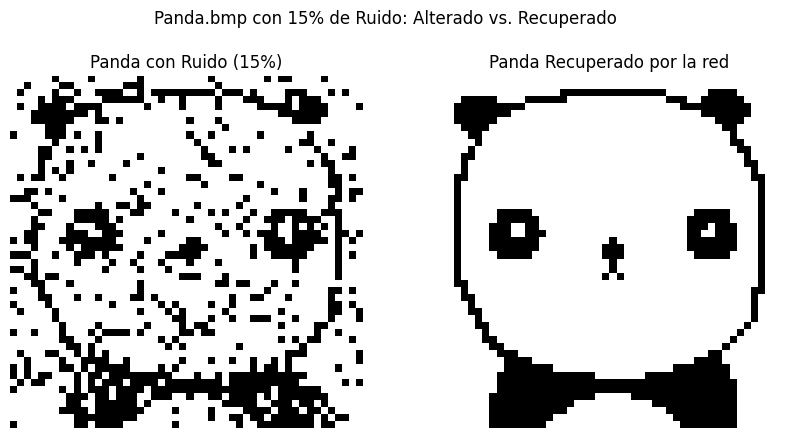

La red tomó 2 iteraciones para recuperar la imagen con 15% de ruido.

--- Añadiendo ruido gaussiano del 30% a 'panda.bmp' ---


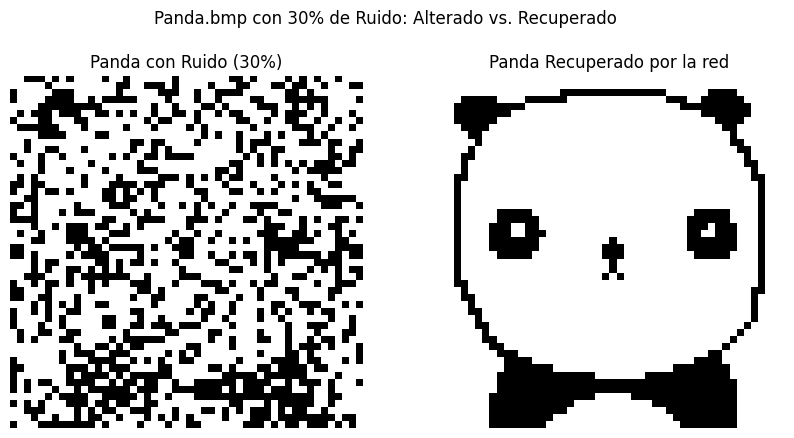

La red tomó 2 iteraciones para recuperar la imagen con 30% de ruido.

--- Añadiendo ruido gaussiano del 50% a 'panda.bmp' ---


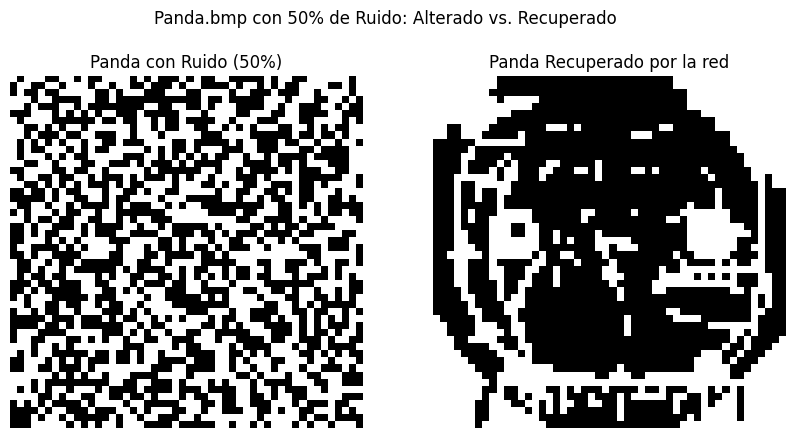

La red tomó 2 iteraciones para recuperar la imagen con 50% de ruido.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_neurons = patterns_selected.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(patterns_selected)

def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

# 1. Obtener el patrón original de panda.bmp y su forma una sola vez
idx_panda = selected_image_files.index('panda.bmp')
oriented_panda_pattern_flat = patterns_selected[idx_panda].copy()
oriented_panda_shape = image_shapes_selected['panda.bmp']
height, width = oriented_panda_shape
total_pixels = height * width

# Definir las intensidades de ruido (porcentaje de píxeles a invertir)
flip_probabilities = [0.15, 0.30, 0.50] # 15%, 30%, 50%

print("Evaluando la recuperación de 'panda.bmp' con ruido gaussiano de diferentes intensidades...")

for flip_probability in flip_probabilities:
    print(f"\n--- Añadiendo ruido gaussiano del {int(flip_probability*100)}% a 'panda.bmp' ---")

    # Empezar con el patrón original para cada iteración
    modified_panda_pattern_flat = oriented_panda_pattern_flat.copy()

    # Generar una máscara de ruido para invertir los píxeles
    noise_mask = np.random.rand(total_pixels) < flip_probability

    # Aplicar el ruido: invertir los píxeles seleccionados
    modified_panda_pattern_flat[noise_mask] *= -1

    # Pasar la imagen modificada por la función retrieve de la red de Hopfield
    retrieved_panda_pattern, _, actual_iterations = hopfield_network.retrieve(modified_panda_pattern_flat)

    # Imprimir la imagen con ruido y la imagen recuperada
    plt.figure(figsize=(10, 5))
    plt.suptitle(f'Panda.bmp con {int(flip_probability*100)}% de Ruido: Alterado vs. Recuperado')

    plt.subplot(1, 2, 1)
    plot_pattern(adapt_for_plot(modified_panda_pattern_flat), oriented_panda_shape, f'Panda con Ruido ({int(flip_probability*100)}%)')

    plt.subplot(1, 2, 2)
    plot_pattern(adapt_for_plot(retrieved_panda_pattern), oriented_panda_shape, 'Panda Recuperado por la red')
    plt.show()

    # Aclarar el número de iteraciones
    print(f"La red tomó {actual_iterations} iteraciones para recuperar la imagen con {int(flip_probability*100)}% de ruido.")

Demostrando estados espurios: Probando la estabilidad de imágenes invertidas...

Procesando: panda.bmp (colores invertidos)


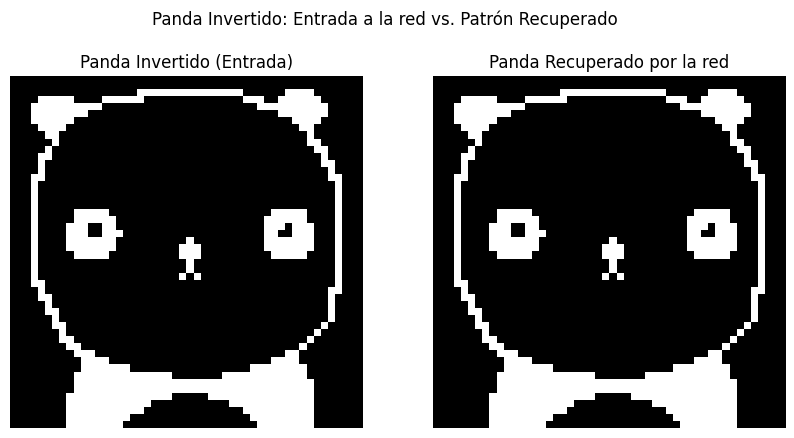

La red tomó 1 iteraciones para recuperar la imagen del panda invertida.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_neurons = patterns_selected.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(patterns_selected)

def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

print("Demostrando estados espurios: Probando la estabilidad de imágenes invertidas...")

# 1. Obtener el patrón original de panda.bmp y su forma
idx_panda = selected_image_files.index('panda.bmp')
original_panda_pattern_flat = patterns_selected[idx_panda].copy()
oriented_panda_shape = image_shapes_selected['panda.bmp']

# 2. Invertir los colores de la imagen del panda
# Simplemente multiplicamos por -1 para invertir los valores (1 a -1, -1 a 1)
inverted_panda_pattern_flat = original_panda_pattern_flat * -1

print(f"\nProcesando: panda.bmp (colores invertidos)")

# 3. Pasar la imagen invertida a la red de Hopfield
retrieved_pattern_from_inverted, _, actual_iterations = hopfield_network.retrieve(inverted_panda_pattern_flat)

# 4. Imprimir la imagen invertida y la recuperada por la red
plt.figure(figsize=(10, 5))
plt.suptitle('Panda Invertido: Entrada a la red vs. Patrón Recuperado')

plt.subplot(1, 2, 1)
plot_pattern(adapt_for_plot(inverted_panda_pattern_flat), oriented_panda_shape, 'Panda Invertido (Entrada)')

plt.subplot(1, 2, 2)
plot_pattern(adapt_for_plot(retrieved_pattern_from_inverted), oriented_panda_shape, 'Panda Recuperado por la red')
plt.show()

# 5. Aclarar el número de iteraciones
print(f"La red tomó {actual_iterations} iteraciones para recuperar la imagen del panda invertida.")


Generando un patrón combinado (estado espurio) a partir de Panda, Perro y V...
Patrón generado a partir de la combinación de 'panda.bmp', 'perro.bmp' y 'v.bmp'.


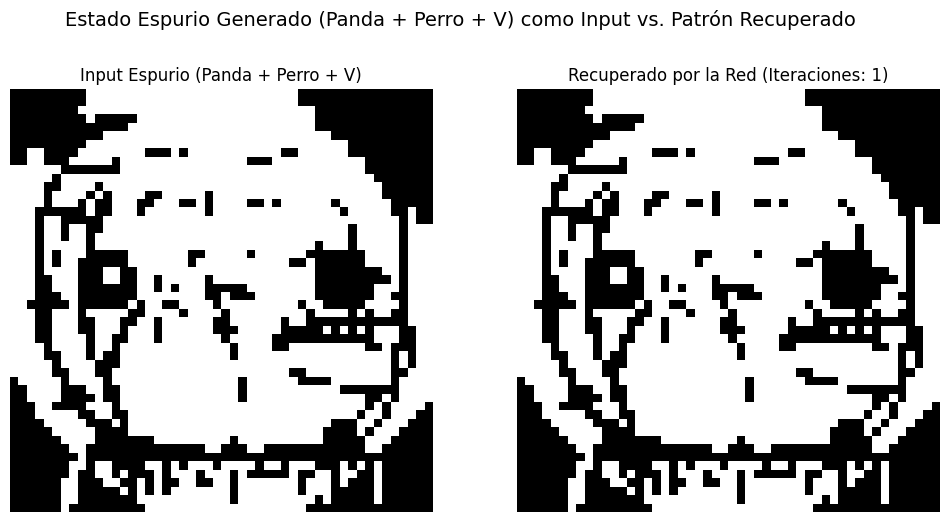

La red tomó 1 iteraciones para recuperar la imagen desde el patrón espurio generado.
El patrón recuperado NO converge a ninguno de los patrones almacenados directamente. 
  Es un estado espurio o un estado fijo no trivial de la red.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Re-using helper functions and trained network from previous cells
# (adapt_for_plot, plot_pattern, hopfield_network, all_patterns, all_image_files, all_image_shapes are assumed to be in scope)

print("\nGenerando un patrón combinado (estado espurio) a partir de Panda, Perro y V...")

# Obtener los patrones originales de panda, perro y v de 'all_patterns'
idx_panda = all_image_files.index('panda.bmp')
idx_perro = all_image_files.index('perro.bmp')
idx_v = all_image_files.index('v.bmp') # Nuevo: Incluir 'v.bmp'

pattern_panda = all_patterns[idx_panda]
pattern_perro = all_patterns[idx_perro]
pattern_v = all_patterns[idx_v] # Nuevo: Patrón de 'v.bmp'

# Obtener la forma de las imágenes (todas son 50x50 para estas)
image_shape_50x50 = all_image_shapes['panda.bmp'] # Usamos la de panda, ya que tienen la misma forma

# Crear un patrón combinado sumando los tres patrones y luego binarizando
# Sumamos los tres patrones y luego binarizamos: >0 se convierte en 1, <=0 se convierte en -1
combined_raw = pattern_panda + pattern_perro + pattern_v # Modificado para sumar 3 patrones
spurious_pattern_input = np.where(combined_raw > 0, 1, -1)

print(f"Patrón generado a partir de la combinación de 'panda.bmp', 'perro.bmp' y 'v.bmp'.")

# Alimentar este nuevo patrón combinado a la red de Hopfield
retrieved_spurious_pattern, history_spurious, actual_iterations_spurious = hopfield_network.retrieve(spurious_pattern_input)

# Graficar el patrón espurio de entrada y el patrón recuperado
plt.figure(figsize=(12, 6))
plt.suptitle('Estado Espurio Generado (Panda + Perro + V) como Input vs. Patrón Recuperado', fontsize=14) # Título actualizado

plt.subplot(1, 2, 1)
plot_pattern(adapt_for_plot(spurious_pattern_input), image_shape_50x50, 'Input Espurio (Panda + Perro + V)') # Título actualizado

plt.subplot(1, 2, 2)
plot_pattern(adapt_for_plot(retrieved_spurious_pattern), image_shape_50x50, f'Recuperado por la Red (Iteraciones: {actual_iterations_spurious})')
plt.show()

print(f"La red tomó {actual_iterations_spurious} iteraciones para recuperar la imagen desde el patrón espurio generado.")

# Verificar si el patrón recuperado coincide con alguno de los patrones almacenados originales
matched_stored_pattern = False
matched_pattern_name = ""
for i, p_stored in enumerate(all_patterns):
    if np.array_equal(retrieved_spurious_pattern, p_stored):
        matched_stored_pattern = True
        matched_pattern_name = all_image_files[i]
        break

if matched_stored_pattern:
    print(f"El patrón recuperado converge a uno de los patrones almacenados: '{matched_pattern_name}'.")
else:
    print("El patrón recuperado NO converge a ninguno de los patrones almacenados directamente. \n  Es un estado espurio o un estado fijo no trivial de la red.")


Adaptando imágenes de 45x60 (alto x ancho) a 50x50 píxeles...

Procesando paloma.bmp...
Dimensiones originales (alto x ancho): 45x60
Dimensiones después del recorte de ancho: 45x50
Dimensiones finales adaptadas: 50x50


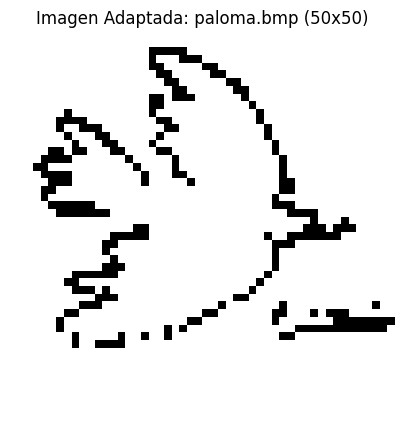


Procesando quijote.bmp...
Dimensiones originales (alto x ancho): 45x60
Dimensiones después del recorte de ancho: 45x50
Dimensiones finales adaptadas: 50x50


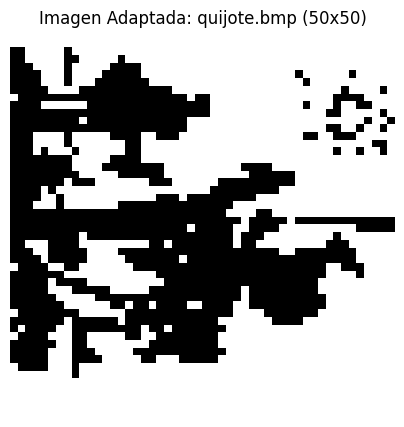


Procesando torero.bmp...
Dimensiones originales (alto x ancho): 45x60
Dimensiones después del recorte de ancho: 45x50
Dimensiones finales adaptadas: 50x50


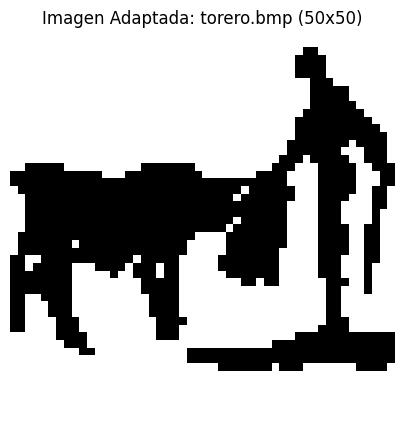

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Helper function to adapt for plotting (1 -> 255, -1 -> 0)
def adapt_for_plot(pattern_flat, shape):
    # Reshape the flat pattern to its original 2D shape
    pattern_2d = pattern_flat.reshape(shape)
    # Convert 1 to 255 (white) and -1 to 0 (black)
    return np.where(pattern_2d == 1, 255, 0)

# Imágenes a adaptar
images_to_adapt = ['paloma.bmp', 'quijote.bmp', 'torero.bmp']
image_dir = 'TP1_rrnn/img/' # Usar la misma ruta de imagen

print("Adaptando imágenes de 45x60 (alto x ancho) a 50x50 píxeles...")

for img_name in images_to_adapt:
    print(f"\nProcesando {img_name}...")
    file_path = os.path.join(image_dir, img_name)

    # Cargar la imagen y seleccionar un solo canal, luego binarizar
    img_data = mpimg.imread(file_path)
    # Asumimos que la imagen es RGBA o RGB, tomamos el primer canal (rojo)
    img_data_single_channel = img_data[:, :, 0]
    # Binarización: 255 (blanco) -> 1, 0 (negro) -> -1
    binary_img = np.where(img_data_single_channel == 255, 1, -1)

    original_height, original_width = binary_img.shape
    print(f"Dimensiones originales (alto x ancho): {original_height}x{original_width}")

    # Crear una imagen en blanco (negro) de 50x50 para rellenar
    adapted_img_50x50 = np.full((50, 50), -1, dtype=int)

    # 1. Ajustar el ancho (de 60 a 50): Recortar 5 columnas de cada lado
    # Esto tomará las columnas de la 5 a la 54 (índices 0-based), resultando en 50 columnas
    cropped_width_img = binary_img[:, 5:original_width-5]
    current_height, current_width = cropped_width_img.shape
    print(f"Dimensiones después del recorte de ancho: {current_height}x{current_width}")

    # 2. Ajustar la altura (de 45 a 50): Añadir 5 filas blancas en la parte inferior
    # Copiar la imagen recortada por ancho en las primeras 45 filas del array 50x50
    adapted_img_50x50[0:current_height, :] = cropped_width_img

    # Las filas 45 a 49 (5 filas) ya están en -1. Necesitamos que sean 1 (blanco).
    adapted_img_50x50[current_height:, :] = 1 # Rellenar con blanco

    print(f"Dimensiones finales adaptadas: {adapted_img_50x50.shape[0]}x{adapted_img_50x50.shape[1]}")

    # Visualizar la imagen adaptada
    plt.figure(figsize=(5, 5))
    plt.title(f'Imagen Adaptada: {img_name} (50x50)')
    plt.imshow(adapt_for_plot(adapted_img_50x50.flatten(), adapted_img_50x50.shape), cmap='gray')
    plt.axis('off')
    plt.show()

In [ ]:
# Listas para almacenar los patrones adaptados de las nuevas imágenes
adapted_patterns_new_images = []
image_shapes_new_images = {}

# Recorrer las imágenes adaptadas de la celda anterior
# Necesitamos simular el bucle de la celda oVTHkQYQhdbg para obtener los patrones.
# Es mejor si la celda oVTHkQYQhdbg devuelve o guarda estas variables.
# Para evitar re-ejecutar el proceso, asumiré que adapted_img_50x50 y img_name
# del último ciclo de oVTHkQYQhdbg están disponibles si esa celda se ejecutó.
# Sin embargo, para un código robusto, lo ideal sería que oVTHkQYQhdbg guardara una lista de todos.

# Para este propósito, iteraremos a través de images_to_adapt y recrearemos los patrones.
# Esto es redundante si oVTHkQYQhdbg ya lo hizo y los guardó, pero asegura que estén disponibles.
images_to_adapt = ['paloma.bmp', 'quijote.bmp', 'torero.bmp'] # Redefinir si no está en el scope global

for img_name in images_to_adapt:
    file_path = os.path.join(image_dir, img_name)
    img_data = mpimg.imread(file_path)
    img_data_single_channel = img_data[:, :, 0]
    binary_img = np.where(img_data_single_channel == 255, 1, -1)

    original_height, original_width = binary_img.shape
    cropped_width_img = binary_img[:, 5:original_width-5]
    current_height, current_width = cropped_width_img.shape

    adapted_img_50x50 = np.full((50, 50), -1, dtype=int)
    adapted_img_50x50[0:current_height, :] = cropped_width_img
    adapted_img_50x50[current_height:, :] = 1 # Rellenar con blanco

    adapted_patterns_new_images.append(adapted_img_50x50.flatten())
    image_shapes_new_images[img_name] = adapted_img_50x50.shape

# Combinar los patrones seleccionados inicialmente con los nuevos patrones adaptados
all_patterns = np.vstack((patterns_selected, np.array(adapted_patterns_new_images)))

# Combinar las formas de las imágenes
all_image_shapes = {**image_shapes_selected, **image_shapes_new_images}

# Nombres de todas las imágenes (para referencia)
all_image_files = selected_image_files + images_to_adapt

print(f"\nTotal de todos los patrones cargados: {len(all_patterns)}")
print(f"Dimensiones del array de todos los patrones: {all_patterns.shape}")

# Re-entrenar la red de Hopfield con todas las imágenes
num_neurons = all_patterns.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(all_patterns)

print(f"Red de Hopfield re-entrenada con {all_patterns.shape[0]} imágenes (patrones).")


Total de todos los patrones cargados: 6
Dimensiones del array de todos los patrones: (6, 2500)
Red de Hopfield re-entrenada con 6 imágenes (patrones).


Evaluando la recuperación de todas las imágenes con 0% de ruido gaussiano...

Procesando: panda.bmp con ruido del 0%


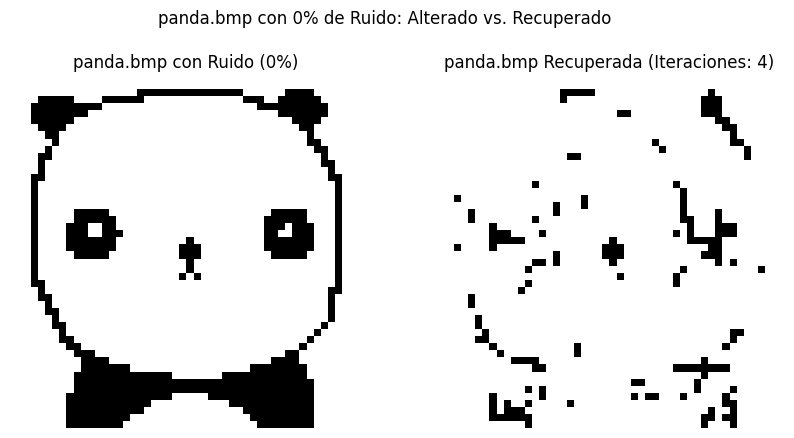

La red tomó 4 iteraciones para recuperar la imagen con 0% de ruido.

Procesando: perro.bmp con ruido del 0%


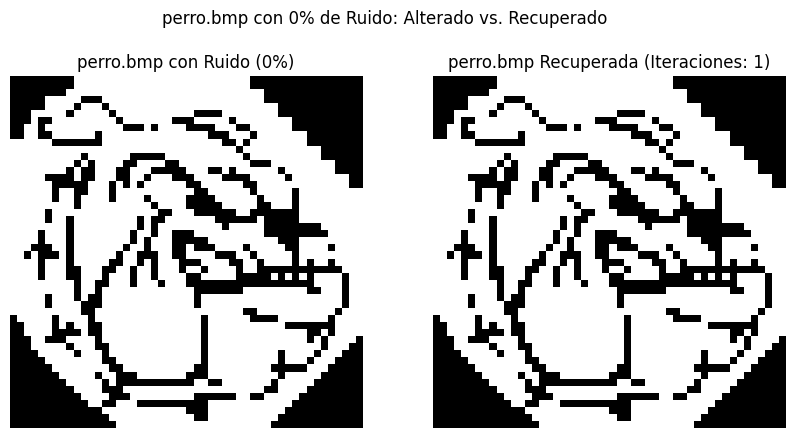

La red tomó 1 iteraciones para recuperar la imagen con 0% de ruido.

Procesando: v.bmp con ruido del 0%


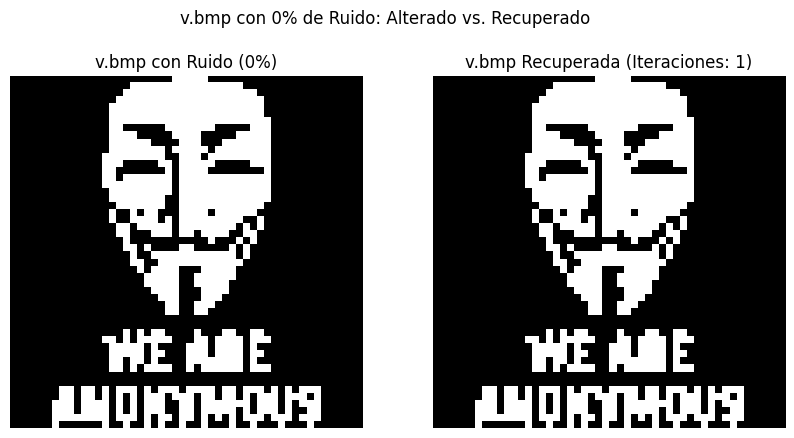

La red tomó 1 iteraciones para recuperar la imagen con 0% de ruido.

Procesando: paloma.bmp con ruido del 0%


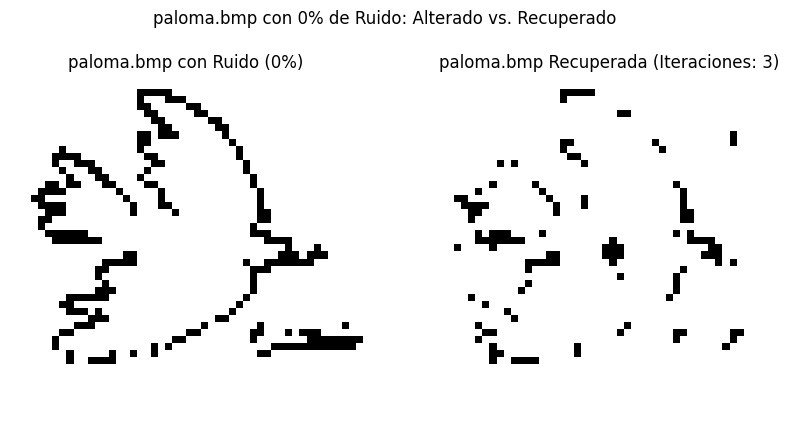

La red tomó 3 iteraciones para recuperar la imagen con 0% de ruido.

Procesando: quijote.bmp con ruido del 0%


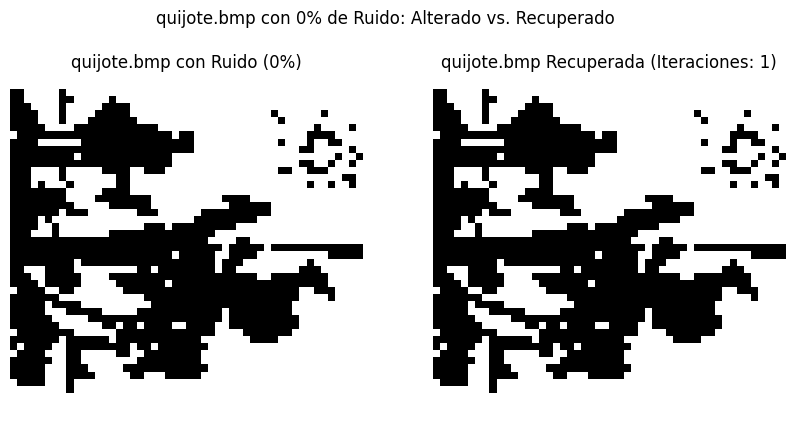

La red tomó 1 iteraciones para recuperar la imagen con 0% de ruido.

Procesando: torero.bmp con ruido del 0%


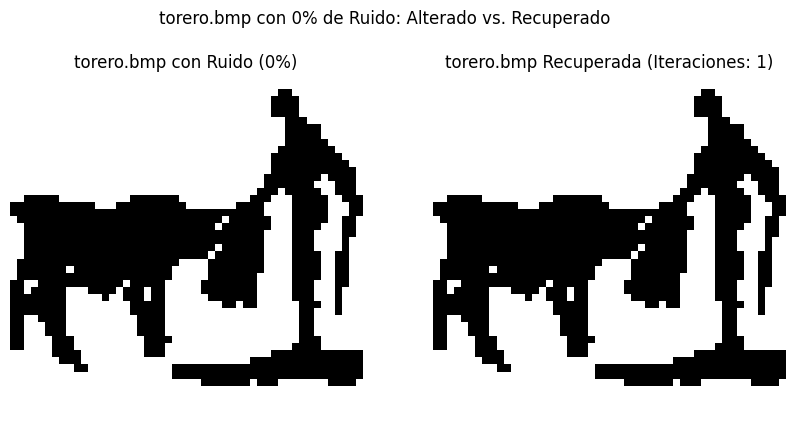

La red tomó 1 iteraciones para recuperar la imagen con 0% de ruido.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_neurons = all_patterns.shape[1]
hopfield_network = HopfieldNetwork(num_neurons).train(all_patterns)

# Helper function to adapt for plotting (1 -> 255, -1 -> 0)
def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

flip_probability = 0.0 # 15% de los píxeles serán invertidos

print(f"Evaluando la recuperación de todas las imágenes con {int(flip_probability*100)}% de ruido gaussiano...")

# Iterar sobre todos los patrones (los 3 originales + los 3 adaptados)
for i, original_pattern_flat in enumerate(all_patterns):
    img_file = all_image_files[i]
    original_shape = all_image_shapes[img_file]
    height, width = original_shape
    total_pixels = height * width

    print(f"\nProcesando: {img_file} con ruido del {int(flip_probability*100)}%")

    # Crear una versión con ruido de la imagen
    modified_pattern_flat = original_pattern_flat.copy()
    noise_mask = np.random.rand(total_pixels) < flip_probability
    modified_pattern_flat[noise_mask] *= -1

    # Pasar la imagen ruidosa por la red de Hopfield
    retrieved_pattern, _, actual_iterations = hopfield_network.retrieve(modified_pattern_flat)

    # Imprimir la imagen ruidosa y la recuperada
    plt.figure(figsize=(10, 5))
    plt.suptitle(f'{img_file} con {int(flip_probability*100)}% de Ruido: Alterado vs. Recuperado')

    plt.subplot(1, 2, 1)
    plot_pattern(adapt_for_plot(modified_pattern_flat), original_shape, f'{img_file} con Ruido ({int(flip_probability*100)}%)')

    plt.subplot(1, 2, 2)
    plot_pattern(adapt_for_plot(retrieved_pattern), original_shape, f'{img_file} Recuperada (Iteraciones: {actual_iterations})')
    plt.show()

    print(f"La red tomó {actual_iterations} iteraciones para recuperar la imagen con {int(flip_probability*100)}% de ruido.")

Mostrando todas las iteraciones de recuperación para Panda y Paloma...

Procesando todas las iteraciones para: panda.bmp
La red tomó 4 iteraciones para recuperar 'panda.bmp'


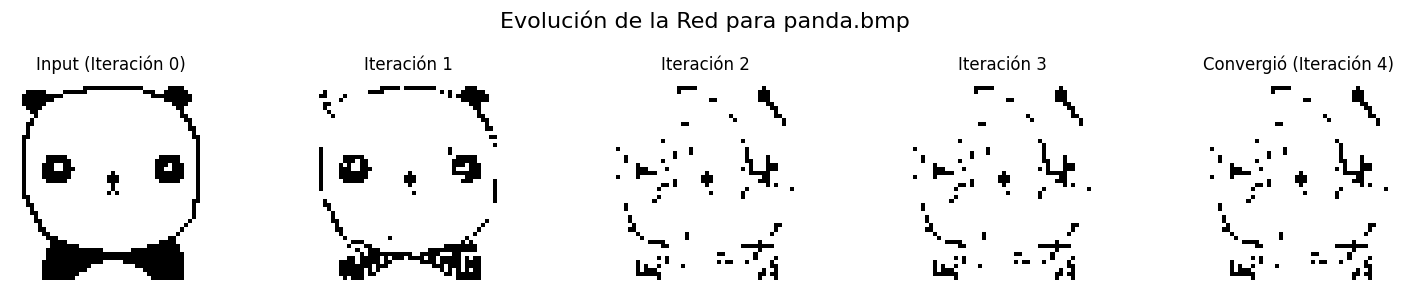


Procesando todas las iteraciones para: paloma.bmp
La red tomó 3 iteraciones para recuperar 'paloma.bmp'


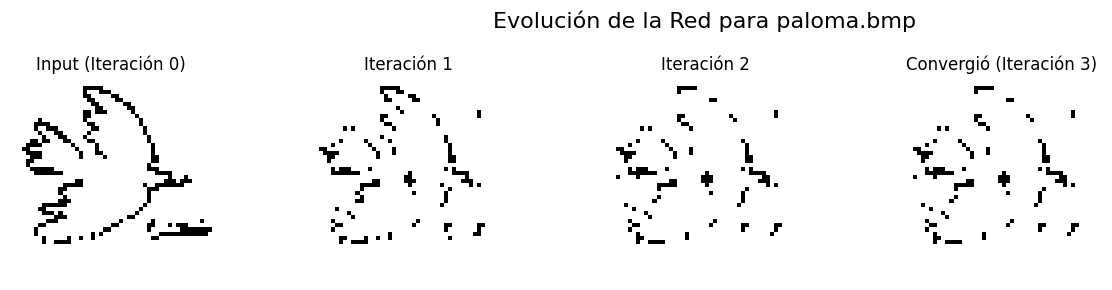

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function to adapt for plotting (1 -> 255, -1 -> 0)
def adapt_for_plot(pattern):
    return np.where(pattern == 1, 255, 0)

# Establecemos una probabilidad de ruido pequeña para la entrada inicial
# para que no converja en 1 iteración y veamos la evolución.
initial_noise_probability = 0.0 # 10% de ruido inicial para mostrar evolución

images_to_show_iterations = ['panda.bmp', 'paloma.bmp']

print("Mostrando todas las iteraciones de recuperación para Panda y Paloma...")

for img_file in images_to_show_iterations:
    print(f"\nProcesando todas las iteraciones para: {img_file}")

    # Obtener el patrón original y su forma
    # Usamos all_patterns y all_image_shapes que ya contienen las 6 imágenes
    idx = all_image_files.index(img_file)
    original_pattern_flat = all_patterns[idx].copy()
    original_shape = all_image_shapes[img_file]
    height, width = original_shape
    total_pixels = height * width

    # Crear una versión con ruido para la entrada inicial
    modified_pattern_flat = original_pattern_flat.copy()
    noise_mask = np.random.rand(total_pixels) < initial_noise_probability
    modified_pattern_flat[noise_mask] *= -1

    # Pasar la imagen ruidosa por la red de Hopfield para obtener la historia completa
    retrieved_pattern, history, actual_iterations = hopfield_network.retrieve(modified_pattern_flat)

    print(f"La red tomó {actual_iterations} iteraciones para recuperar '{img_file}'")

    # Visualizar cada estado en el historial
    num_plots = len(history)
    rows = int(np.ceil(num_plots / 5.0)) # 5 imágenes por fila para mantener un buen formato

    plt.figure(figsize=(15, rows * 3))
    plt.suptitle(f'Evolución de la Red para {img_file}', fontsize=16)

    for j, state_flat in enumerate(history):
        plt.subplot(rows, 5, j + 1)
        if j == 0:
            title = f'Input (Iteración 0)'
        elif j == actual_iterations:
            title = f'Convergió (Iteración {j})'
        else:
            title = f'Iteración {j}'
        plot_pattern(adapt_for_plot(state_flat), original_shape, title)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el título superior
    plt.show()